# Propensity score

- This notebook estimates the effect of a manager-training intervention on
  employee engagement from observational data, using propensity scores to
  correct for the fact that treated and control managers differ
- The pedagogical arc:
  - Exploratory analysis of the management-training data
  - Naive and covariate-adjusted treatment effect estimates
  - Estimating the propensity score and adjusting for it
  - Propensity score matching and inverse probability of treatment
    weighting (IPTW)
  - Variance of the IPW estimator, via bootstrap confidence intervals
  - Stabilized propensity weights

In [30]:
%load_ext autoreload
%autoreload 2

import logging

import pandas as pd
import statsmodels.formula.api as smf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import helpers.hnotebook as hnotebook
import helpers.hpandas_display as hpandisp
import helpers.hpandas_stats as hpanstat

import L08_04_05_propensity_score_utils as utils

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
_LOG = logging.getLogger(__name__)
utils.init_loggers(_LOG)

# Convert `display` into `print()` when running outside IPython.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

In [2]:
dir_name = "L08_data"
!ls $dir_name

out_dir_name = "figures/"

# Part 1: Exploratory Analysis

## Cell 1.1: Loading the management-training data

**Goal**
- Load the manager-training dataset used throughout this notebook

The dataset contains information on managers with the following
variables:
- **intervention**: binary treatment indicator (1 = received training, 0
  = control)
- **engagement_score**: primary outcome: average standardized engagement
  score of the manager's employees
- **department_id**: unique department identifier
- **tenure**: years the manager has been with the company
- **n_of_reports**: number of direct reports the manager has
- **gender**: manager's identified gender (categorical)
- **role**: job category within the company (categorical)
- **department_size**: number of employees in the department
- **department_score**: average engagement score in the department
- **last_engagement_score**: previous period's engagement score for the
  manager

In [3]:
df = pd.read_csv(f"{dir_name}/management_training.csv")
hpandisp.display_df(df)

pymc is not installed
arviz is not installed
preliz is not installed
sns is not installed


Python 3.12.13
Linux 3f3aef6a9c0f 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 GNU/Linux


## Cell 1.2: Exploring distributions and correlations

**Goal**
- Check the distribution of each variable, and how variables correlate
  with each other, before fitting any model

**Implementation** `hpanstat.explore_dataframe(df, ...)`

INFO:helpers.hpandas_stats:stats_df=


,num_rows,zeros [%],nans [%],infs [%],valid [%],num_unique,unique [%]
departament_id,10391,0.0,0.0,0.0,100.0,76,0.73
intervention,10391,46.0,0.0,0.0,54.0,2,0.02
engagement_score,10391,0.0,0.0,0.0,100.0,10391,100.0
tenure,10391,0.0,0.0,0.0,100.0,7,0.07
n_of_reports,10391,0.0,0.0,0.0,100.0,8,0.08
gender,10391,0.0,0.0,0.0,100.0,2,0.02
role,10391,8.13,0.0,0.0,91.87,5,0.05
last_engagement_score,10391,0.0,0.0,0.0,100.0,10391,100.0
department_score,10391,0.0,0.0,0.0,100.0,76,0.73
department_size,10391,0.0,0.0,0.0,100.0,72,0.69


INFO:helpers.hpandas_stats:Univariate distributions:


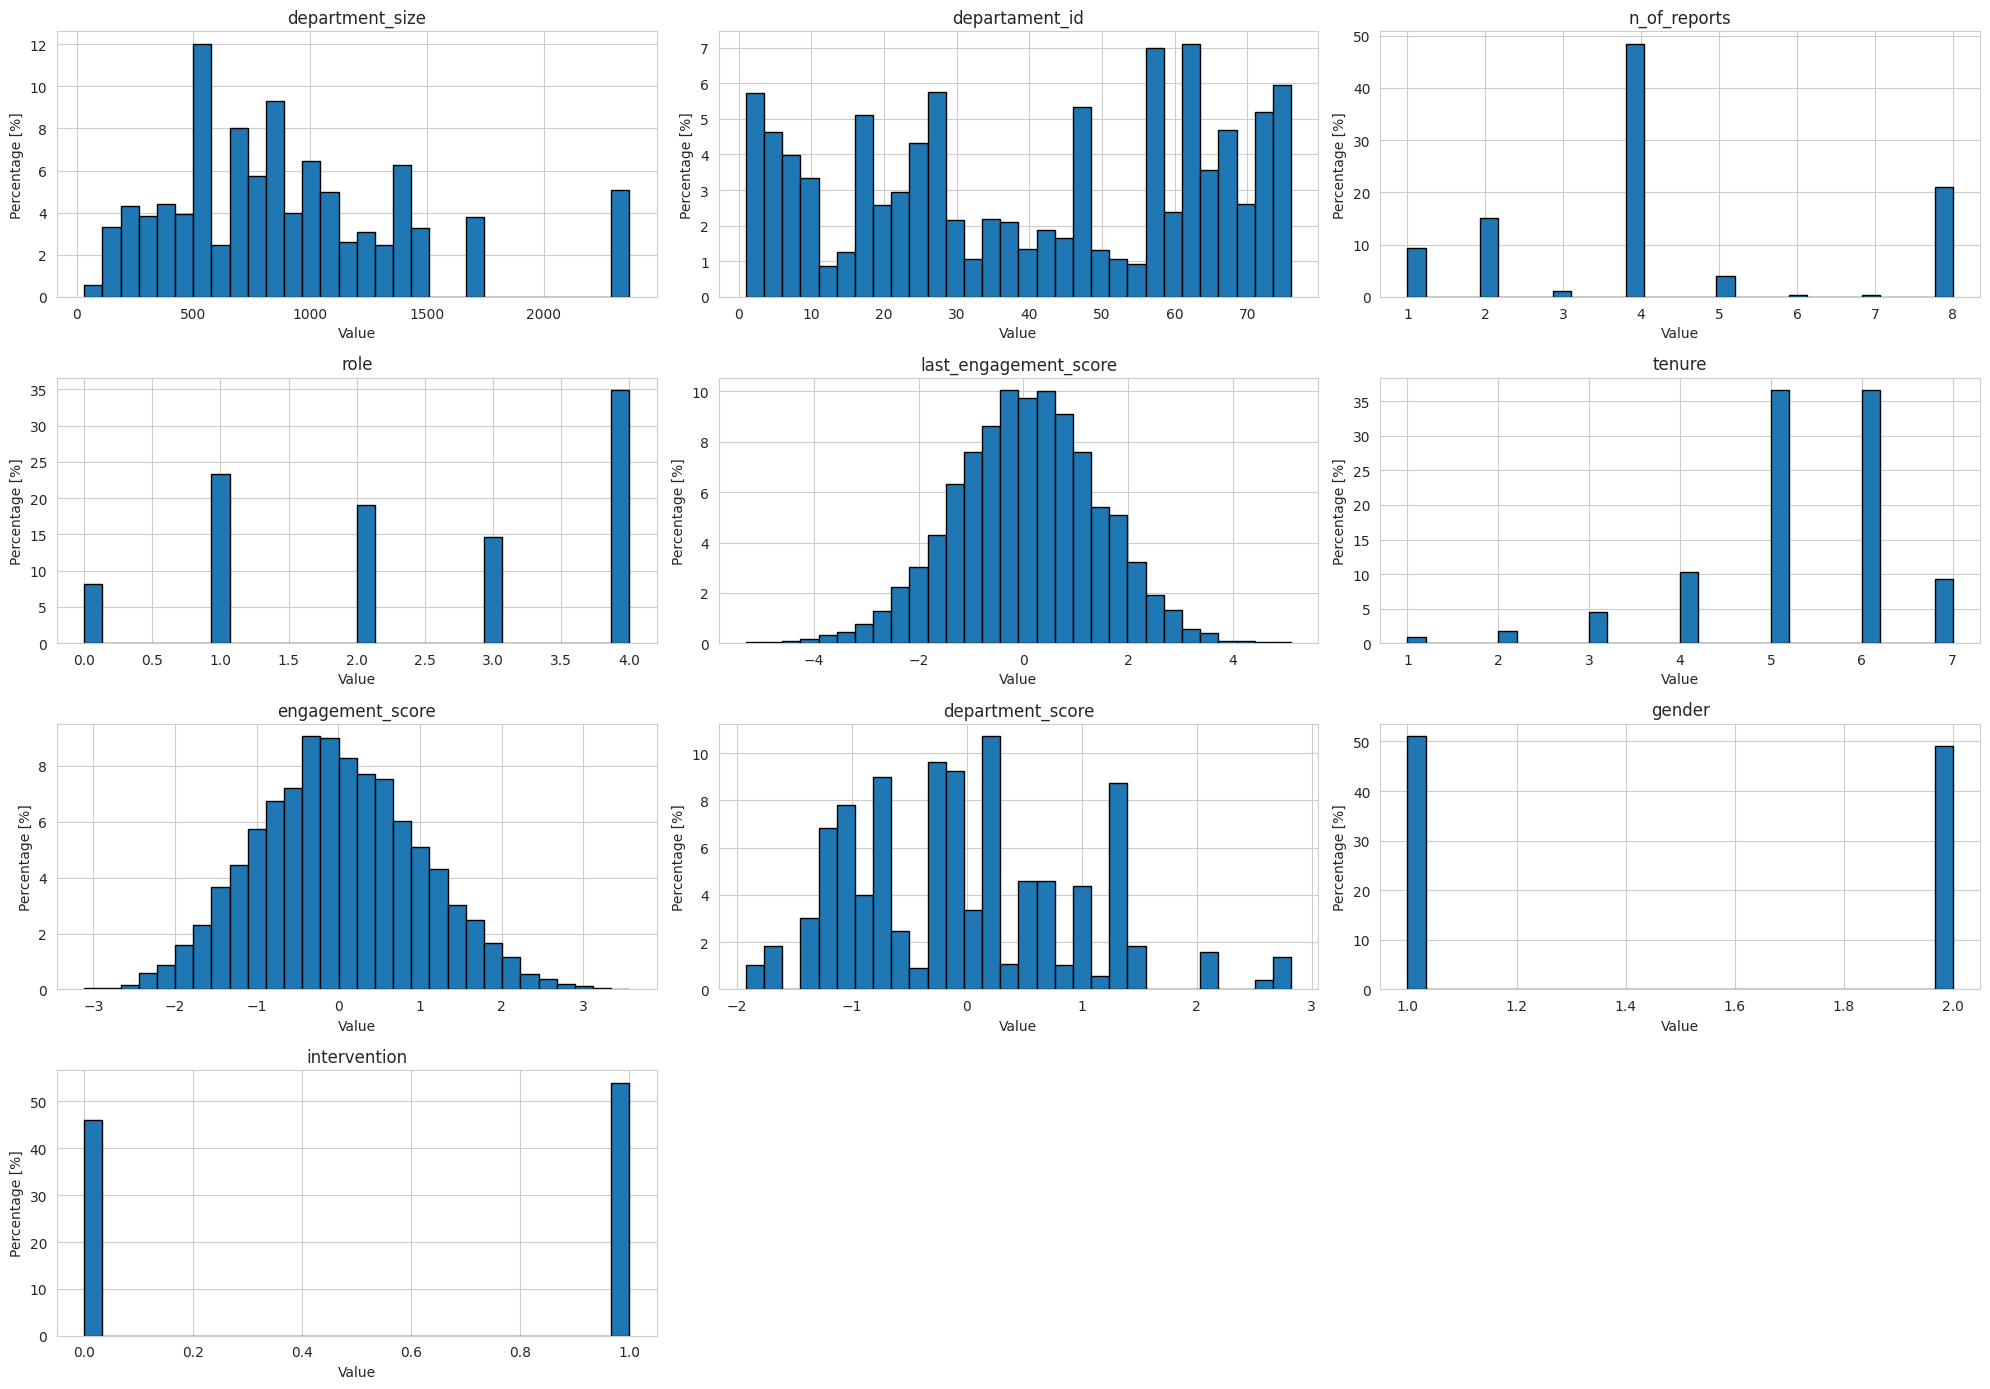

INFO:helpers.hpandas_stats:Correlation matrix:


,departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size
departament_id,1.000000,0.002266,-0.078337,0.029178,0.053808,0.006494,0.141227,0.027869,0.121768,0.259454
intervention,0.002266,1.000000,0.216614,0.199276,0.000497,-0.031315,-0.026555,0.104083,-0.065904,0.063432
engagement_score,-0.078337,0.216614,1.000000,0.438577,-0.008746,-0.159343,0.051367,0.011241,0.013696,0.006148
tenure,0.029178,0.199276,0.438577,1.000000,-0.009208,-0.043800,-0.029627,0.053055,-0.052548,0.036704
n_of_reports,0.053808,0.000497,-0.008746,-0.009208,1.000000,-0.008218,-0.024649,0.030823,-0.053213,0.027211
gender,0.006494,-0.031315,-0.159343,-0.043800,-0.008218,1.000000,0.008840,0.000496,0.005535,0.004224
role,0.141227,-0.026555,0.051367,-0.029627,-0.024649,0.008840,1.000000,-0.123305,0.401507,0.159458
last_engagement_score,0.027869,0.104083,0.011241,0.053055,0.030823,0.000496,-0.123305,1.000000,-0.281688,0.275172
department_score,0.121768,-0.065904,0.013696,-0.052548,-0.053213,0.005535,0.401507,-0.281688,1.000000,-0.088321
department_size,0.259454,0.063432,0.006148,0.036704,0.027211,0.004224,0.159458,0.275172,-0.088321,1.000000


In [6]:
show_distributions = True
show_correlations = True

hpanstat.explore_dataframe(
    df,
    show_distributions=show_distributions,
    show_correlations=show_correlations,
)

# Part 2: Naive Treatment Effect

## Cell 2.1: Estimating the unadjusted average treatment effect

**Goal**
- Estimate the treatment effect by regressing the outcome on the
  treatment indicator alone, ignoring all other covariates

**Implementation** `smf.ols("engagement_score ~ intervention", data=df)`

In [7]:
model = smf.ols("engagement_score ~ intervention", data=df).fit()
print("ATE:", model.params["intervention"])
print("95% CI:", model.conf_int().loc["intervention", :].values.T)

display(model.summary().tables[1])

## Cell 2.2: Visualizing engagement by treatment status

**Goal**
- Visualize the raw relationship between treatment and outcome, both
  overall and split by department

**Implementation** `utils.plot_engagement_vs_intervention(df)`,
`utils.plot_engagement_vs_intervention_by_department(df)`

In [8]:
utils.plot_engagement_vs_intervention(df)

ATE: 0.43459886274141496
95% CI: [0.39693035 0.47226738]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.2347,0.014,-16.619,0.000,-0.262,-0.207
intervention,0.4346,0.019,22.616,0.000,0.397,0.472


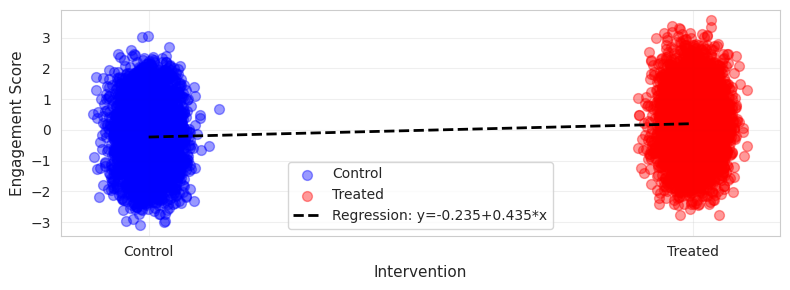

In [9]:
utils.plot_engagement_vs_intervention_by_department(df)

## Cell 2.3: Visualizing every covariate by treatment status

**Goal**
- Check whether the treated and control groups differ on any observed
  covariate, which would indicate confounding

**Implementation** `utils.plot_all_variables_density_by_intervention(df)`

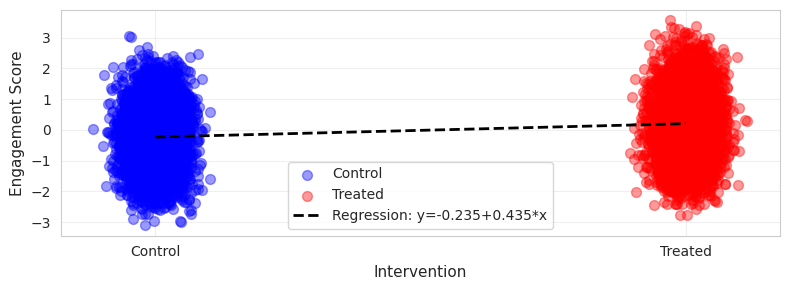

In [10]:
utils.plot_all_variables_density_by_intervention(df)

## Cell 2.4: Adjusting for covariates

**Goal**
- Re-estimate the treatment effect while adjusting for the observed
  covariates, to see how much the naive estimate was biased

**Implementation**
- `smf.ols("engagement_score ~ intervention + tenure + ...", data=df)`

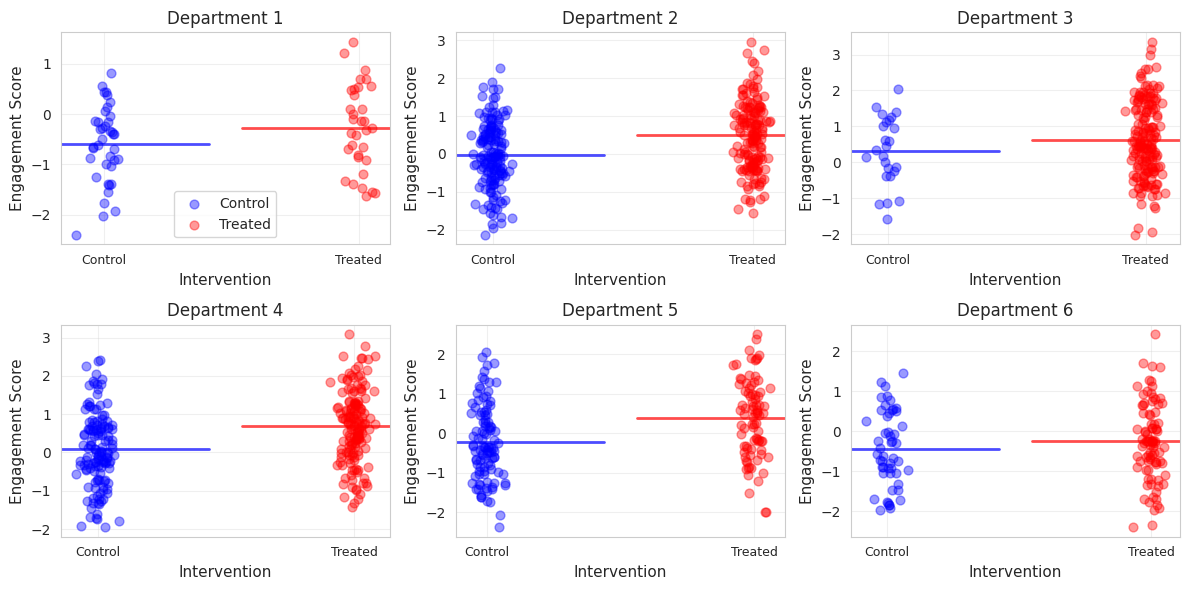

In [11]:
# To reduce this bias, you can adjust for the covariates you have in your data.
model_adj = smf.ols(
    """
    engagement_score ~ intervention
        + tenure + last_engagement_score + department_score
        + n_of_reports + C(gender) + C(role)""",
    data=df,
).fit()

print("ATE (adjusted):", model_adj.params["intervention"])
print("95% CI (adjusted):", model_adj.conf_int().loc["intervention", :].values.T)
print("ATE (naive):", model.params["intervention"])
print("95% CI (naive):", model.conf_int().loc["intervention", :].values.T)

- The adjusted effect estimate is considerably smaller than the naive
  one
- This is some indication of positive bias: managers whose employees
  were already more engaged are more likely to have participated in the
  manager training program

# Part 3: Propensity Score

## Cell 3.1: Estimating the propensity score

**Goal**
- Fit a propensity-score model, the probability of treatment given
  covariates, to later use as a single balancing score

**Implementation** `smf.logit("intervention ~ ...", data=df)`

In [12]:
ps_model = smf.logit(
    """
    intervention ~
        tenure + last_engagement_score + department_score
        + C(n_of_reports) + C(gender) + C(role)""",
    data=df,
).fit(disp=0)

data_ps = df.copy()
data_ps["propensity_score"] = ps_model.predict(df)

display(data_ps[["intervention", "engagement_score", "propensity_score"]].head())

## Cell 3.2: Adjusting for the propensity score directly

**Goal**
- Use the propensity score itself as a single covariate, instead of the
  full covariate set, to adjust for confounding

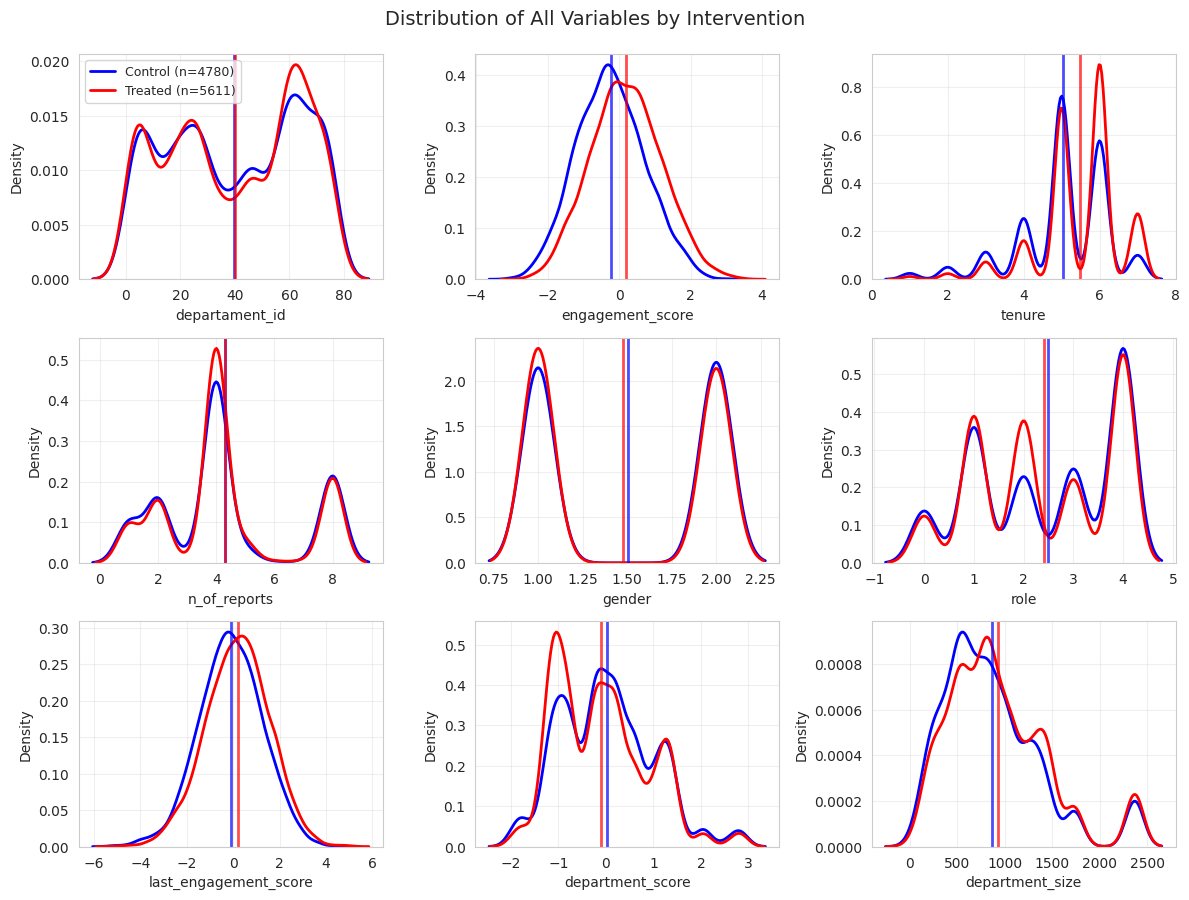

In [13]:
# Estimate using propensity score as confounder / covariate.
model_ps = smf.ols(
    "engagement_score ~ intervention + propensity_score",
    data=data_ps,
).fit()
print("ATE (propensity-score covariate):", model_ps.params["intervention"])

# Part 4: Propensity Score Matching

## Cell 4.1: Matching on the propensity score

**Goal**
- Estimate the ATE by matching each treated unit to its nearest control
  unit (and vice versa) on the propensity score

**Implementation** `utils.propensity_score_matching(data_ps)`,
`utils.calculate_psm_ate(predicted)`

In [14]:
# Perform 1-nearest neighbor propensity score matching.
predicted = utils.propensity_score_matching(data_ps)
display(predicted.head())

ATE: 0.26779085766768607
95% CI: [0.23357751 0.30200421]


In [15]:
# Calculate average treatment effect from propensity score matching.
hat_ATE = utils.calculate_psm_ate(predicted)
print(f"ATE (propensity score matching): {hat_ATE:.4f}")

ATE: 0.43459886274141496
95% CI: [0.39693035 0.47226738]


## Cell 4.2: Inverse probability of treatment weighting

**Goal**
- Estimate the ATE by reweighting units by the inverse of their
  propensity score, instead of matching

**Implementation** `utils.plot_iptw(data_ps)`,
`utils.estimate_ate_iptw(data_ps)`

In [ ]:
# Plot inverse probability of treatment weighting results.
utils.plot_iptw(data_ps)

In [ ]:
# Estimate ATE using IPTW.
weighted_e_y1, weighted_e_y0, hat_ATE = utils.estimate_ate_iptw(data_ps)

print("E[Y1]:", weighted_e_y1)
print("E[Y0]:", weighted_e_y0)
print("ATE:", hat_ATE)

# Part 5: Variance of the IPW Estimator

## Cell 5.1: Estimating the ATE with bootstrap confidence intervals

**Goal**
- Quantify the uncertainty of the IPW estimator via bootstrap
  resampling, since it has no simple closed-form standard error

**Implementation** `utils.estimate_ate_with_ps(...)`,
`utils.estimate_confidence_interval_bootstrap(...)`

In [ ]:
# Prepare formula and variables for IPW estimation.
formula = """
tenure + last_engagement_score + department_score
    + C(n_of_reports) + C(gender) + C(role)
"""
treatment_col = "intervention"
outcome_col = "engagement_score"

In [ ]:
# Estimate ATE using IPW estimator.
ate_ipw = utils.estimate_ate_with_ps(
    df, formula, treatment_col=treatment_col, outcome_col=outcome_col
)
print(f"ATE (IPW): {ate_ipw:.4f}")

In [ ]:
# Compute bootstrap 95% confidence interval for ATE using IPW.
est_fn = lambda data: utils.estimate_ate_with_ps(
    data,
    ps_formula=formula,
    treatment_col=treatment_col,
    outcome_col=outcome_col,
)

ci = utils.estimate_confidence_interval_bootstrap(
    df, est_fn, rounds=200, seed=123, n_jobs=4, pcts=[2.5, 97.5]
)
print(f"ATE: {ate_ipw:.4f}")
print(f"95% confidence interval: {ci}")

# Part 6: Stabilized Propensity Weights

## Cell 6.1: Checking the pseudo-population sample sizes

**Goal**
- Check how many "effective" units the IPTW pseudo-population represents
  for each group, since extreme propensity scores can inflate a few
  units' weight far beyond their actual count

In [ ]:
# Show sample sizes for original and pseudo-population.
print("Original sample size:", data_ps.shape[0])

# Compute sample sizes after IPTW weighting.
treated = data_ps.query("intervention==1")
control = data_ps.query("intervention==0")

weight_t = 1 / treated["propensity_score"]
weight_nt = 1 / (1 - control["propensity_score"])

print("Treated pseudo-population sample size:", sum(weight_t))
print("Untreated pseudo-population sample size:", sum(weight_nt))

## Cell 6.2: Estimating the ATE with stabilized weights

**Goal**
- Re-estimate the ATE with stabilized weights, which rescale by the
  marginal treatment probability to reduce the influence of extreme
  propensity scores

**Implementation** `utils.estimate_ate_stabilized_weights(data_ps)`,
`utils.plot_propensity_distributions(data_ps)`

In [ ]:
# Estimate ATE using stabilized propensity weights.
ate_stabilized = utils.estimate_ate_stabilized_weights(data_ps)
print(f"ATE (stabilized weights): {ate_stabilized:.4f}")

In [ ]:
# Plot propensity score distributions before and after weighting.
utils.plot_propensity_distributions(data_ps)